# Reactor Simulator with Monte Carlo Methods

## Opis projektu

Projekt przedstawia uproszczoną, stochastyczną symulację procesu transportu neutronów w modelu reaktora jądrowego. Celem projektu jest demonstracja metod Monte Carlo w symulacji procesów losowych, a nie wierne odwzorowanie fizyki reaktorowej.

Model obejmuje:
- ruch neutronów w przestrzeni 3D,
- losowe zderzenia z jądrami atomowymi,
- procesy: rozpraszanie, absorpcja i rozszczepienie,
- estymację efektywnego współczynnika mnożenia neutronów (k_eff),
- wizualizację oraz analizę statystyczną wyników wielu symulacji.
---


`config.py`

Plik konfiguracyjny parametrów modelu:

- Geometria:
    - REACTOR_RADIUS – promień reaktora (obszar symulacji)
    - NUM_NUCLEI – liczba jąder atomowych w przestrzeni
    - NUCLEUS_INTERACTION_RADIUS – promień oddziaływania neutron–jądro
- Neutrony:
    - INITIAL_NEUTRONS – liczba neutronów startowych
    - MAX_NEUTRONS – maksymalna liczba neutronów w symulacji
    - MAX_SECONDARY_NEUTRONS – limit neutronów wtórnych z jednego rozszczepienia
- Transport:
    - MEAN_FREE_PATH – średnia droga swobodna neutronu (długość kroku ruchu)
    - MAX_STEPS – maksymalna liczba kroków symulacji
- Prawdopodobieństwa reakcji:
    - P_FISSION – prawdopodobieństwo rozszczepienia
    - P_ABSORPTION – prawdopodobieństwo absorpcji neutronu
    - P_SCATTER – prawdopodobieństwo rozpraszania
- Produkcja neutronów:
    - MEAN_SECONDARY_NEUTRONS – średnia liczba neutronów wtórnych (rozkład Poissona)
- Wizualizacja:
    - TRAIL_LIFETIME – czas życia śladu neutronu
    - MAX_TRAIL_PER_NEUTRON – maksymalna długość śladu
    - SIM_STEPS_PER_FRAME – liczba kroków symulacji na klatkę animacji

In [17]:
REACTOR_RADIUS = 10

NUM_NUCLEI = 1000
NUCLEUS_INTERACTION_RADIUS = 0.25

INITIAL_NEUTRONS = 10
MEAN_FREE_PATH = 0.5

P_FISSION = 0.6
P_ABSORPTION = 0.25
P_SCATTER = 0.15

MEAN_SECONDARY_NEUTRONS = 2.5

MAX_STEPS = 100

MAX_NEUTRONS = 300
MAX_SECONDARY_NEUTRONS = 2

TRAIL_LIFETIME = 25
MAX_TRAIL_PER_NEUTRON = 40
SIM_STEPS_PER_FRAME = 1

`nucleus.py`

Definicja jądra atomowego:
- position – stała pozycja w przestrzeni

In [18]:
from dataclasses import dataclass
import numpy as np

@dataclass
class Nucleus:
    position: np.ndarray

`neutron.py`

Definicja obiektu neutronu:
- id – identyfikator
- position – pozycja w 3D
- direction – kierunek ruchu
- alive – status aktywności

In [19]:
from dataclasses import dataclass
import numpy as np

@dataclass
class Neutron:
    id: int
    position: np.ndarray
    direction: np.ndarray
    alive: bool = True

`physics.py`

Warstwa fizyczna modelu:
- losowy ruch neutronów (eksponencjalny krok)
- generowanie kierunków (wektory jednostkowe)
- detekcja interakcji z jądrami
- obsługa reakcji:
    - absorpcja
    - rozpraszanie
    - rozszczepienie (generacja neutronów wtórnych)

In [20]:
import numpy as np
from config import (
    REACTOR_RADIUS,
    MEAN_FREE_PATH,
    P_ABSORPTION,
    P_SCATTER,
    MEAN_SECONDARY_NEUTRONS,
    MAX_SECONDARY_NEUTRONS
)

from neutron import Neutron


def random_unit_vector():
    v = np.random.normal(size=3)
    return v / np.linalg.norm(v)


def random_position_in_sphere(radius=REACTOR_RADIUS):
    while True:
        p = np.random.uniform(-radius, radius, size=3)
        if np.linalg.norm(p) <= radius:
            return p


def move_neutron(position, direction):
    step = np.random.exponential(MEAN_FREE_PATH)
    return position + direction * step


def is_inside_reactor(position):
    return np.linalg.norm(position) <= REACTOR_RADIUS


def handle_interaction(neutron, neutrons_list, next_id):
    r = np.random.random()

    if r < P_ABSORPTION:
        neutron.alive = False
        return "absorption", next_id

    elif r < P_ABSORPTION + P_SCATTER:
        neutron.direction = random_unit_vector()
        return "scatter", next_id

    else:
        neutron.alive = False

        n_new = np.random.poisson(MEAN_SECONDARY_NEUTRONS)
        n_new = min(n_new, MAX_SECONDARY_NEUTRONS)

        for _ in range(n_new):
            neutrons_list.append(
                Neutron(
                    id=next_id,
                    position=neutron.position.copy(),
                    direction=random_unit_vector()
                )
            )
            next_id += 1

        return "fission", next_id

`simulation.py`

Główny silnik symulacji:
- inicjalizacja neutronów i jąder
- wykonanie kroków transportu neutronów
- obsługa reakcji fizycznych (fission, absorption, scatter)
- agregacja wyników jednej i wielu symulacji

In [21]:
import numpy as np
from scipy.spatial import cKDTree

from neutron import Neutron
from nucleus import Nucleus

from physics import (
    random_position_in_sphere,
    random_unit_vector,
    move_neutron,
    is_inside_reactor,
    handle_interaction
)

from config import (
    INITIAL_NEUTRONS,
    NUM_NUCLEI,
    NUCLEUS_INTERACTION_RADIUS,
    MAX_NEUTRONS,
    TRAIL_LIFETIME,
    MAX_TRAIL_PER_NEUTRON,
    MAX_STEPS
)


def create_initial_neutrons(next_id=0):
    neutrons = []

    for _ in range(INITIAL_NEUTRONS):
        neutrons.append(
            Neutron(
                id=next_id,
                position=random_position_in_sphere(),
                direction=random_unit_vector()
            )
        )
        next_id += 1

    return neutrons, next_id


def create_nuclei():
    nuclei = [
        Nucleus(position=random_position_in_sphere())
        for _ in range(NUM_NUCLEI)
    ]

    tree = cKDTree(np.array([n.position for n in nuclei]))
    return nuclei, tree


def run_transport_step(neutrons, tree, next_id, trajectories):

    new_neutrons = []
    current_positions = []

    fissions = 0
    absorptions = 0
    scatterings = 0

    for n in neutrons:

        n.position = move_neutron(n.position, n.direction)

        if not is_inside_reactor(n.position):
            continue

        traj = trajectories.setdefault(n.id, [])
        traj.append((n.position.copy(), TRAIL_LIFETIME))

        current_positions.append(n.position.copy())

        hits = tree.query_ball_point(n.position, r=NUCLEUS_INTERACTION_RADIUS)

        if len(hits) == 0:
            new_neutrons.append(n)
            continue

        reaction, next_id = handle_interaction(n, new_neutrons, next_id)

        if reaction == "fission":
            fissions += 1
        elif reaction == "absorption":
            absorptions += 1
        elif reaction == "scatter":
            scatterings += 1
            new_neutrons.append(n)

    if len(new_neutrons) > MAX_NEUTRONS:
        new_neutrons = new_neutrons[:MAX_NEUTRONS]

    for tid in list(trajectories.keys()):
        new_traj = []

        for pos, life in trajectories[tid]:
            life -= 1
            if life > 0:
                new_traj.append((pos, life))

        trajectories[tid] = new_traj

        if len(trajectories[tid]) > MAX_TRAIL_PER_NEUTRON:
            trajectories[tid] = trajectories[tid][-MAX_TRAIL_PER_NEUTRON:]

    return new_neutrons, next_id, current_positions, fissions, absorptions, scatterings


def run_single_simulation():

    neutrons, next_id = create_initial_neutrons()
    nuclei, tree = create_nuclei()

    trajectories = {}

    k_estimates = []

    total_fissions = 0
    total_absorptions = 0
    total_scatterings = 0

    for _ in range(MAX_STEPS):

        neutrons, next_id, _, f, a, s = run_transport_step(
            neutrons,
            tree,
            next_id,
            trajectories
        )

        total_fissions += f
        total_absorptions += a
        total_scatterings += s

        if len(neutrons) > 0:
            k_estimates.append(len(neutrons))

        if len(neutrons) == 0:
            break

    k_estimates = np.array(k_estimates)

    if len(k_estimates) > 0:
        k_mean = np.mean(k_estimates)
        k_std = np.std(k_estimates)
        k_se = k_std / np.sqrt(len(k_estimates))
    else:
        k_mean, k_std, k_se = 0.0, 0.0, 0.0

    return k_mean, k_std, k_se, total_fissions, total_absorptions, total_scatterings


def run_monte_carlo(n_runs=100):

    k_values = []
    k_stds = []
    k_ses = []

    fissions_list = []
    absorptions_list = []
    scatterings_list = []

    for i in range(n_runs):

        k_mean, k_std, k_se, f, a, s = run_single_simulation()

        k_values.append(k_mean)
        k_stds.append(k_std)
        k_ses.append(k_se)

        fissions_list.append(f)
        absorptions_list.append(a)
        scatterings_list.append(s)

        print(f"Run {i}: k_eff={k_mean:.4f}, f={f}, a={a}, s={s}")

    k_values = np.array(k_values)
    k_ses = np.array(k_ses)

    results = {
        "k_eff": k_values,
        "k_std": np.array(k_stds),
        "k_se": k_ses,
        "fissions": np.array(fissions_list),
        "absorptions": np.array(absorptions_list),
        "scatterings": np.array(scatterings_list),
    }

    print("\n=== SUMMARY ===")
    print(f"Mean k_eff: {k_values.mean():.4f}")
    print(f"Std k_eff: {k_values.std():.4f}")

    ci_low = k_values.mean() - 1.96 * k_values.std()
    ci_high = k_values.mean() + 1.96 * k_values.std()

    print(f"95% CI approximate: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"Runs: {n_runs}")

    return results

`plot.py`

Moduł analizy wyników:
- Generuje wykresy:
    - histogram rozkładu k_eff
    - przebieg k_eff w kolejnych symulacjach
    - liczba reakcji (fission / absorption / scattering)
    - liczba przypadków subkrytycznych i superkrytycznych

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_monte_carlo_results(results):
    k_eff = results["k_eff"]
    k_se = results["k_se"]

    fissions = results["fissions"]
    absorptions = results["absorptions"]
    scatterings = results["scatterings"]

    runs = np.arange(len(k_eff))

    plt.figure()
    plt.hist(k_eff, bins=15, alpha=0.8)

    mean_k = k_eff.mean()

    ci_low = mean_k - 1.96 * k_eff.std()
    ci_high = mean_k + 1.96 * k_eff.std()

    plt.axvline(mean_k, linestyle="-", label="mean k_eff")
    plt.axvline(ci_low, linestyle="--", color="red", label="95% CI")
    plt.axvline(ci_high, linestyle="--", color="red")

    plt.axvline(1.0, linestyle=":", label="critical k=1")

    plt.title("k_eff distribution (Monte Carlo)")
    plt.xlabel("k_eff")
    plt.ylabel("frequency")
    plt.legend()
    plt.grid(True)

    plt.figure()
    plt.plot(runs, k_eff, marker="o")
    plt.axhline(1.0, linestyle="--", label="critical k=1")
    plt.title("k_eff per simulation run")
    plt.xlabel("run")
    plt.ylabel("k_eff")
    plt.legend()
    plt.grid(True)

    plt.figure()
    plt.plot(runs, fissions, label="fissions")
    plt.plot(runs, absorptions, label="absorptions")
    plt.plot(runs, scatterings, label="scatterings")
    plt.title("Reaction statistics per run")
    plt.xlabel("run")
    plt.ylabel("count")
    plt.legend()
    plt.grid(True)

    plt.figure()

    sub = np.sum(k_eff < 1)
    superc = np.sum(k_eff >= 1)

    plt.bar(["subcritical", "supercritical"], [sub, superc])
    plt.title("Reactor stability classification")
    plt.ylabel("number of runs")

    plt.show()

`main.py`

Plik startowy dla analizy Monte Carlo:
- uruchamia run_monte_carlo(n)
- wykonuje serię niezależnych symulacji
- generuje wykresy wyników

Run 0: k_eff=5.3846, f=0, a=0, s=0
Run 1: k_eff=2.8913, f=0, a=0, s=0
Run 2: k_eff=4.9310, f=0, a=0, s=0
Run 3: k_eff=3.5441, f=5, a=1, s=0
Run 4: k_eff=4.0294, f=1, a=2, s=0
Run 5: k_eff=3.7297, f=0, a=0, s=0
Run 6: k_eff=3.5135, f=0, a=1, s=1
Run 7: k_eff=5.6774, f=1, a=0, s=0
Run 8: k_eff=4.3714, f=0, a=0, s=1
Run 9: k_eff=4.6250, f=2, a=1, s=0
Run 10: k_eff=5.3774, f=13, a=3, s=1
Run 11: k_eff=5.1500, f=1, a=0, s=0
Run 12: k_eff=4.3750, f=3, a=1, s=1
Run 13: k_eff=4.5882, f=1, a=1, s=2
Run 14: k_eff=3.5814, f=6, a=4, s=1
Run 15: k_eff=4.6667, f=2, a=1, s=0
Run 16: k_eff=4.6364, f=2, a=0, s=1
Run 17: k_eff=5.5517, f=3, a=0, s=1
Run 18: k_eff=4.6316, f=5, a=1, s=0
Run 19: k_eff=6.4857, f=3, a=1, s=0
Run 20: k_eff=2.4324, f=1, a=0, s=0
Run 21: k_eff=5.3659, f=1, a=1, s=1
Run 22: k_eff=3.6562, f=1, a=0, s=0
Run 23: k_eff=4.9643, f=1, a=1, s=0
Run 24: k_eff=4.7391, f=6, a=2, s=0
Run 25: k_eff=2.5000, f=1, a=1, s=0
Run 26: k_eff=7.1905, f=0, a=0, s=0
Run 27: k_eff=5.0250, f=1, a=1, s=0
R

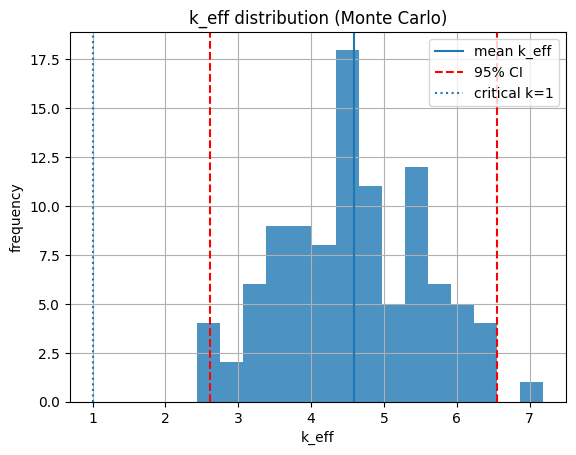

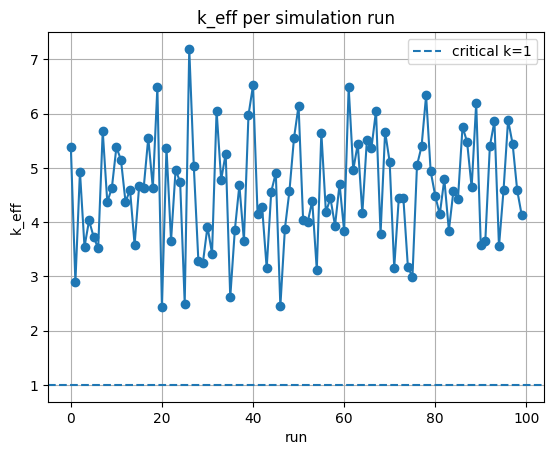

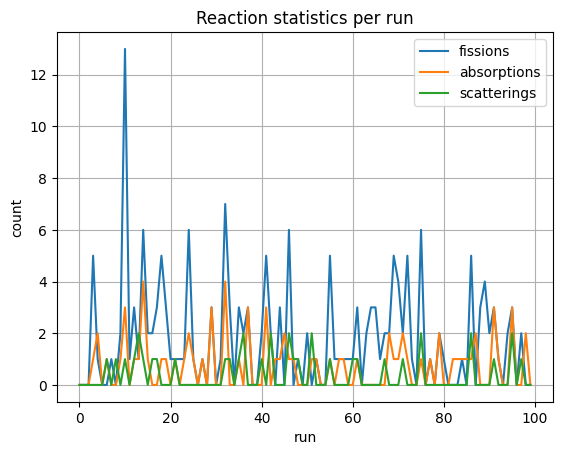

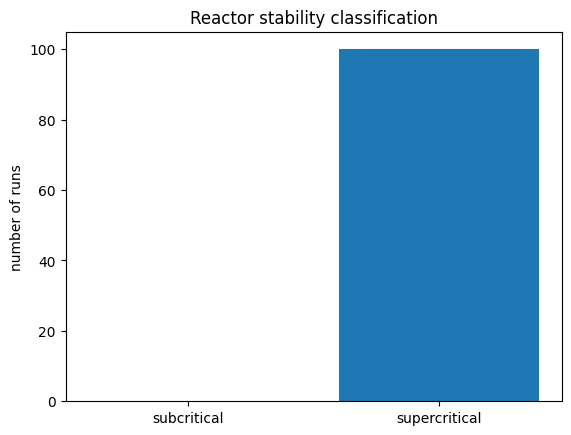

In [23]:
from simulation import run_monte_carlo
from plot import plot_monte_carlo_results

results = run_monte_carlo(100)

plot_monte_carlo_results(results)

`vispy_engine.py`

Silnik wizualizacji 3D:
- realtime rendering neutronów i jąder
- animacja ruchu i trajektorii
- aktualizacja symulacji w czasie rzeczywistym

**Uwaga!**  \
Biblioteka używana do symulacji 3D sprawia problemy w Jupyter Notebooks, dlatego w razie problemów proszę ręcznie uruchomić plik ```vispy_engine.py```

In [16]:
import numpy as np
from vispy import scene, app

from simulation import (
    create_initial_neutrons,
    create_nuclei,
    run_transport_step
)

from config import SIM_STEPS_PER_FRAME

canvas = scene.SceneCanvas(keys="interactive", show=True, bgcolor="black")
view = canvas.central_widget.add_view()
view.camera = scene.cameras.TurntableCamera(fov=45)

canvas.title = "Visual simulation"

neutron_plot = scene.visuals.Markers()
view.add(neutron_plot)

line_plot = scene.visuals.Line(color="cyan", width=1)
view.add(line_plot)


neutrons, next_id = create_initial_neutrons()
nuclei, tree = create_nuclei()

trajectories = {}

nuclei_pos = np.array([n.position for n in nuclei])
nuclei_plot = scene.visuals.Markers()
nuclei_plot.set_data(nuclei_pos, face_color="red", size=3)
view.add(nuclei_plot)


def update(event):

    global neutrons, next_id, trajectories

    all_positions = []

    for _ in range(SIM_STEPS_PER_FRAME):

        neutrons, next_id, positions, f, a, s = run_transport_step(
            neutrons,
            tree, 
            next_id,
            trajectories
        )

        all_positions.extend(positions)

        if len(neutrons) == 0:
            neutrons, next_id = create_initial_neutrons()

    if all_positions:
        neutron_plot.set_data(
            np.array(all_positions),
            face_color="cyan",
            size=4
        )

    all_lines = []

    for traj in trajectories.values():
        if len(traj) > 1:

            filtered = [p for p, life in traj if life > 0]

            if len(filtered) > 1:
                all_lines.append(np.array(filtered))

    if all_lines:
        line_plot.set_data(np.vstack(all_lines))

timer = app.Timer(interval=1/60, connect=update, start=True)

app.run()

RuntimeError: Could not import backend "jupyter_rfb":
The jupyter_rfb backend relies on a the jupyter_rfb library: ``pip install jupyter_rfb``